<a href="https://colab.research.google.com/github/DaniJonesOcean/etc-impacts-great-lakes/blob/main/notebooks/Extratropical_cyclone_impacts_on_the_Great_Lakes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETC Impacts on the Great Lakes: Exploratory Analysis

This notebook provides a concise overview of the CFSR and ERA5 extratropical cyclone datasets used in the ETC impacts analysis. It performs basic cleaning, summarizes the key storm-property variables, and visualizes the raw and transformed impact fields.

This notebook is descriptive rather than archival. It is intended to help understand the datasets and preprocessing choices before the main clustering and impact analyses carried out in later notebooks.

In [17]:
# ------------------------------
# 1. Imports and setup
# ------------------------------
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Resolve repository paths
REPO_ROOT = Path.cwd().resolve().parent
DATA_DIR = REPO_ROOT / "data"

# Make repo importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.pipeline
importlib.reload(src.pipeline)

from src.pipeline import (
    add_season,
    clean_teleconnections,
    build_transformer,
    build_impact_transformer,
)

sns.set_theme(style="whitegrid")

print("Repo root:", REPO_ROOT)
print("Data dir:", DATA_DIR)

Repo root: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes
Data dir: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/data


## Load data and inspect key storm variables

Begin by loading the CFSR and ERA5 storm datasets and examining a small set of storm characteristics that are later used in the clustering analysis.

In [18]:
# ------------------------------
# 2. Load data
# ------------------------------
df_era5 = pd.read_csv(DATA_DIR / "era5_etc.csv")
df_cfsr = pd.read_csv(DATA_DIR / "cfsr_etc.csv")

print("ERA5 shape:", df_era5.shape)
print("CFSR shape:", df_cfsr.shape)

storm_characteristics = [
    "min_p_cent",
    "max_p_grad",
    "max_radius",
    "max_uv",
    "fraction_of_time_in_GLR",
    "maturity_glr0_minus_genesis_ratio",
]

print("\nERA5 summary:")
display(df_era5[storm_characteristics].describe())

print("\nCFSR summary:")
display(df_cfsr[storm_characteristics].describe())

ERA5 shape: (6136, 92)
CFSR shape: (3386, 82)

ERA5 summary:


,min_p_cent,max_p_grad,max_radius,max_uv,fraction_of_time_in_GLR,maturity_glr0_minus_genesis_ratio
count,6136.000000,6136.000000,6136.000000,6136.000000,6136.000000,6136.000000
mean,987.208117,23.937711,1004.338056,107.322702,0.267445,0.264470
std,14.617619,9.923363,413.263217,26.783662,0.243401,0.275026
min,912.387459,8.254450,250.334294,26.424395,0.000000,0.000000
25%,978.938736,16.182580,693.825600,88.093280,0.083333,0.000000
50%,990.359349,21.861112,966.817911,109.310097,0.200000,0.181818
75%,997.982710,29.998305,1273.436163,129.009322,0.400000,0.428571
max,1021.648576,71.210767,3616.098744,222.052990,1.000000,1.000000



CFSR summary:


,min_p_cent,max_p_grad,max_radius,max_uv,fraction_of_time_in_GLR,maturity_glr0_minus_genesis_ratio
count,3318.000000,3386.000000,3386.000000,3386.000000,3386.000000,3386.000000
mean,998.715114,16.141615,1024.543924,106.356429,0.256474,0.273293
std,8.375467,6.076501,408.781027,27.755806,0.233595,0.278045
min,957.616172,7.500833,250.731335,27.280463,-0.600000,-0.166667
25%,993.792852,11.517613,718.372935,86.096260,0.085714,0.000000
50%,999.659375,14.919219,990.349583,109.679214,0.192308,0.191392
75%,1004.516387,19.375731,1301.463182,128.297991,0.375000,0.444444
max,1022.841953,44.551383,3234.263229,194.783500,1.000000,1.000000


## Basic cleaning

Next, remove duplicated columns if needed, add seasonal labels, clean teleconnection variables, and filter clearly invalid values from the CFSR dataset.

In [19]:
# ------------------------------
# 3. Basic cleaning
# ------------------------------
df_era5 = df_era5.loc[:, ~df_era5.columns.duplicated()].copy()
df_cfsr = df_cfsr.loc[:, ~df_cfsr.columns.duplicated()].copy()

for df in (df_era5, df_cfsr):
    add_season(df)
    clean_teleconnections(df)

df_cfsr = df_cfsr[
    (df_cfsr["fraction_of_time_in_GLR"] >= 0)
    & (df_cfsr["maturity_glr0_minus_genesis_ratio"] >= 0)
].copy()

print("ERA5 shape after cleaning:", df_era5.shape)
print("CFSR shape after cleaning:", df_cfsr.shape)

ERA5 shape after cleaning: (6136, 93)
CFSR shape after cleaning: (3384, 83)


## Storm-property distributions

These plots compare the distributions of the main storm characteristics across CFSR and ERA5. The goal here is simply to understand the broad structure of the two datasets before any transformation or clustering.

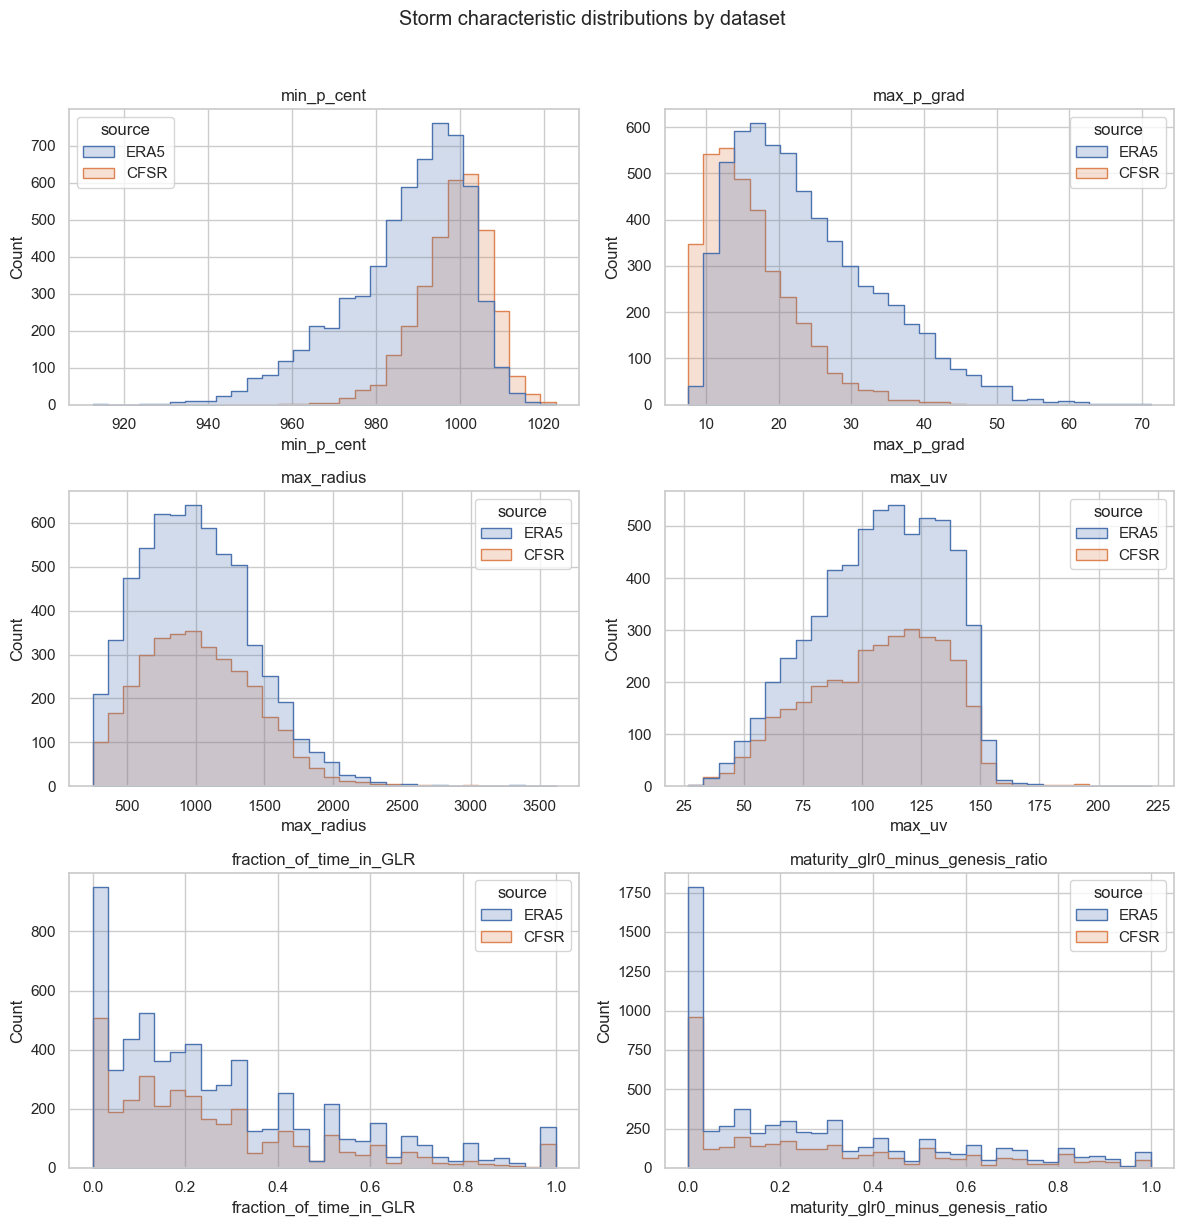

In [20]:
# ------------------------------
# 4. Storm-property distributions
# ------------------------------
df_era5["source"] = "ERA5"
df_cfsr["source"] = "CFSR"
df_all = pd.concat([df_era5, df_cfsr], ignore_index=True)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.ravel()

for ax, var in zip(axes, storm_characteristics):
    sns.histplot(
        data=df_all,
        x=var,
        hue="source",
        bins=30,
        element="step",
        stat="count",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(var)

fig.suptitle("Storm characteristic distributions by dataset", y=1.02)
plt.tight_layout()
plt.show()

## Raw impact distributions

Next, compare the raw precipitation totals and evaporation anomalies across the five Great Lakes. These plots give a basic sense of the magnitude and shape of the impact distributions in the two datasets.

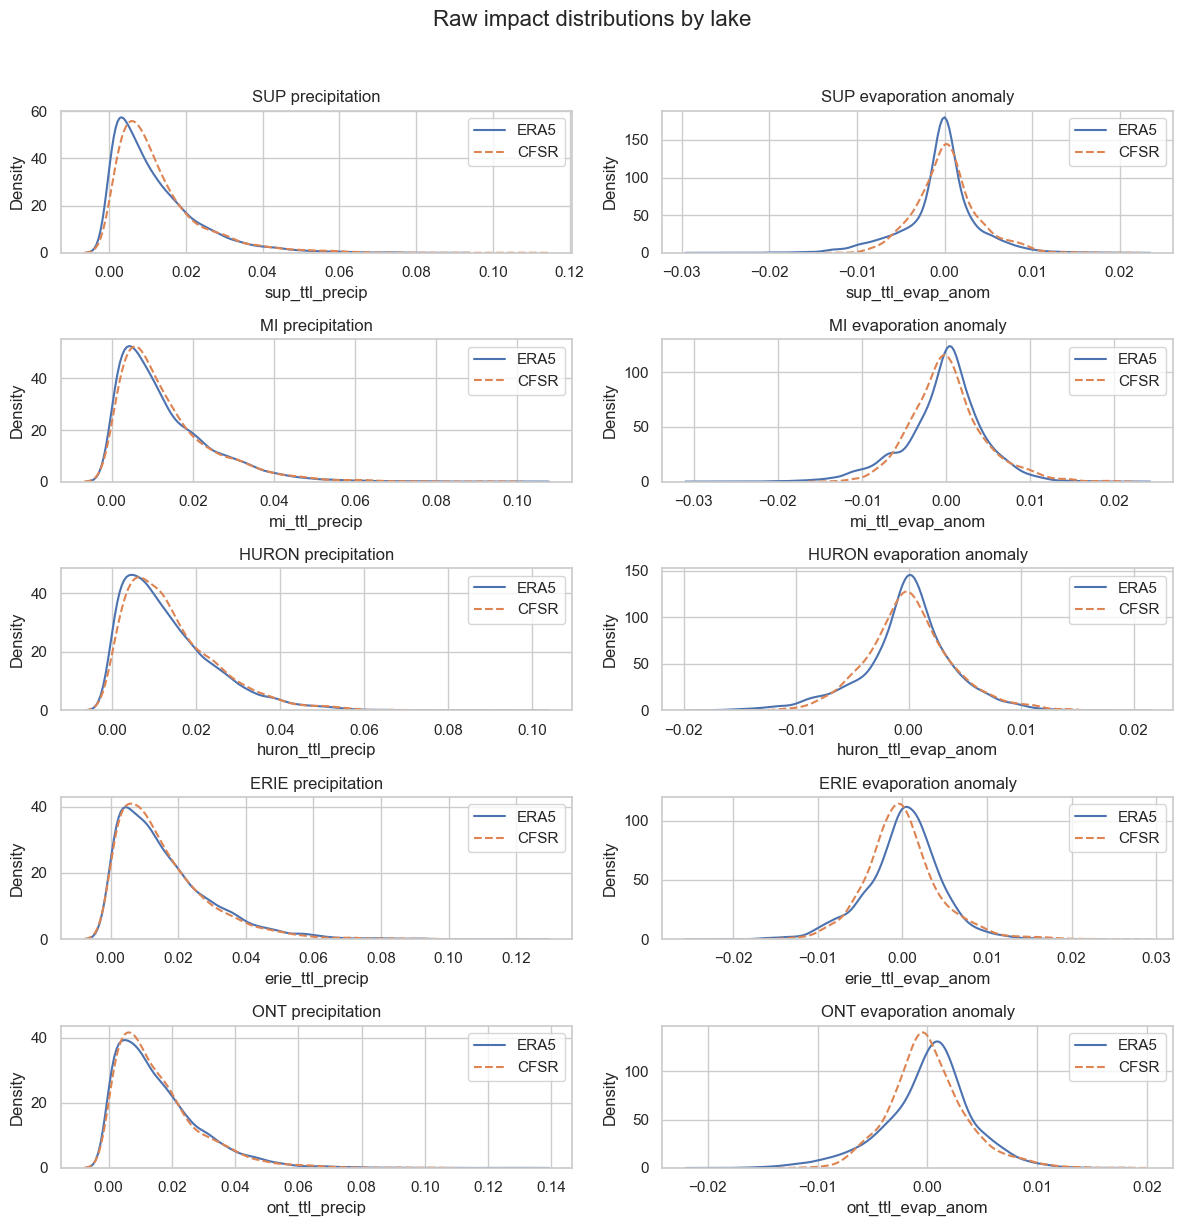

In [21]:
# ------------------------------
# 5. Raw impact distributions
# ------------------------------
lakes = ["sup", "mi", "huron", "erie", "ont"]
precip_vars = [f"{lake}_ttl_precip" for lake in lakes]
evap_anom_vars = [f"{lake}_ttl_evap_anom" for lake in lakes]
impact_vars = precip_vars + evap_anom_vars

fig, axs = plt.subplots(len(lakes), 2, figsize=(12, 12), sharex=False)
fig.suptitle("Raw impact distributions by lake", fontsize=16, y=1.02)

for i, lake in enumerate(lakes):
    precip_col = f"{lake}_ttl_precip"
    evap_col = f"{lake}_ttl_evap_anom"

    sns.kdeplot(df_era5[precip_col], ax=axs[i, 0], label="ERA5")
    sns.kdeplot(df_cfsr[precip_col], ax=axs[i, 0], label="CFSR", linestyle="--")
    axs[i, 0].set_title(f"{lake.upper()} precipitation")
    axs[i, 0].legend()

    sns.kdeplot(df_era5[evap_col], ax=axs[i, 1], label="ERA5")
    sns.kdeplot(df_cfsr[evap_col], ax=axs[i, 1], label="CFSR", linestyle="--")
    axs[i, 1].set_title(f"{lake.upper()} evaporation anomaly")
    axs[i, 1].legend()

plt.tight_layout()
plt.show()

## Feature transformation

The clustering and impact analyses use transformed versions of the storm-property and impact variables. Here we apply those preprocessing pipelines and inspect the transformed distributions.

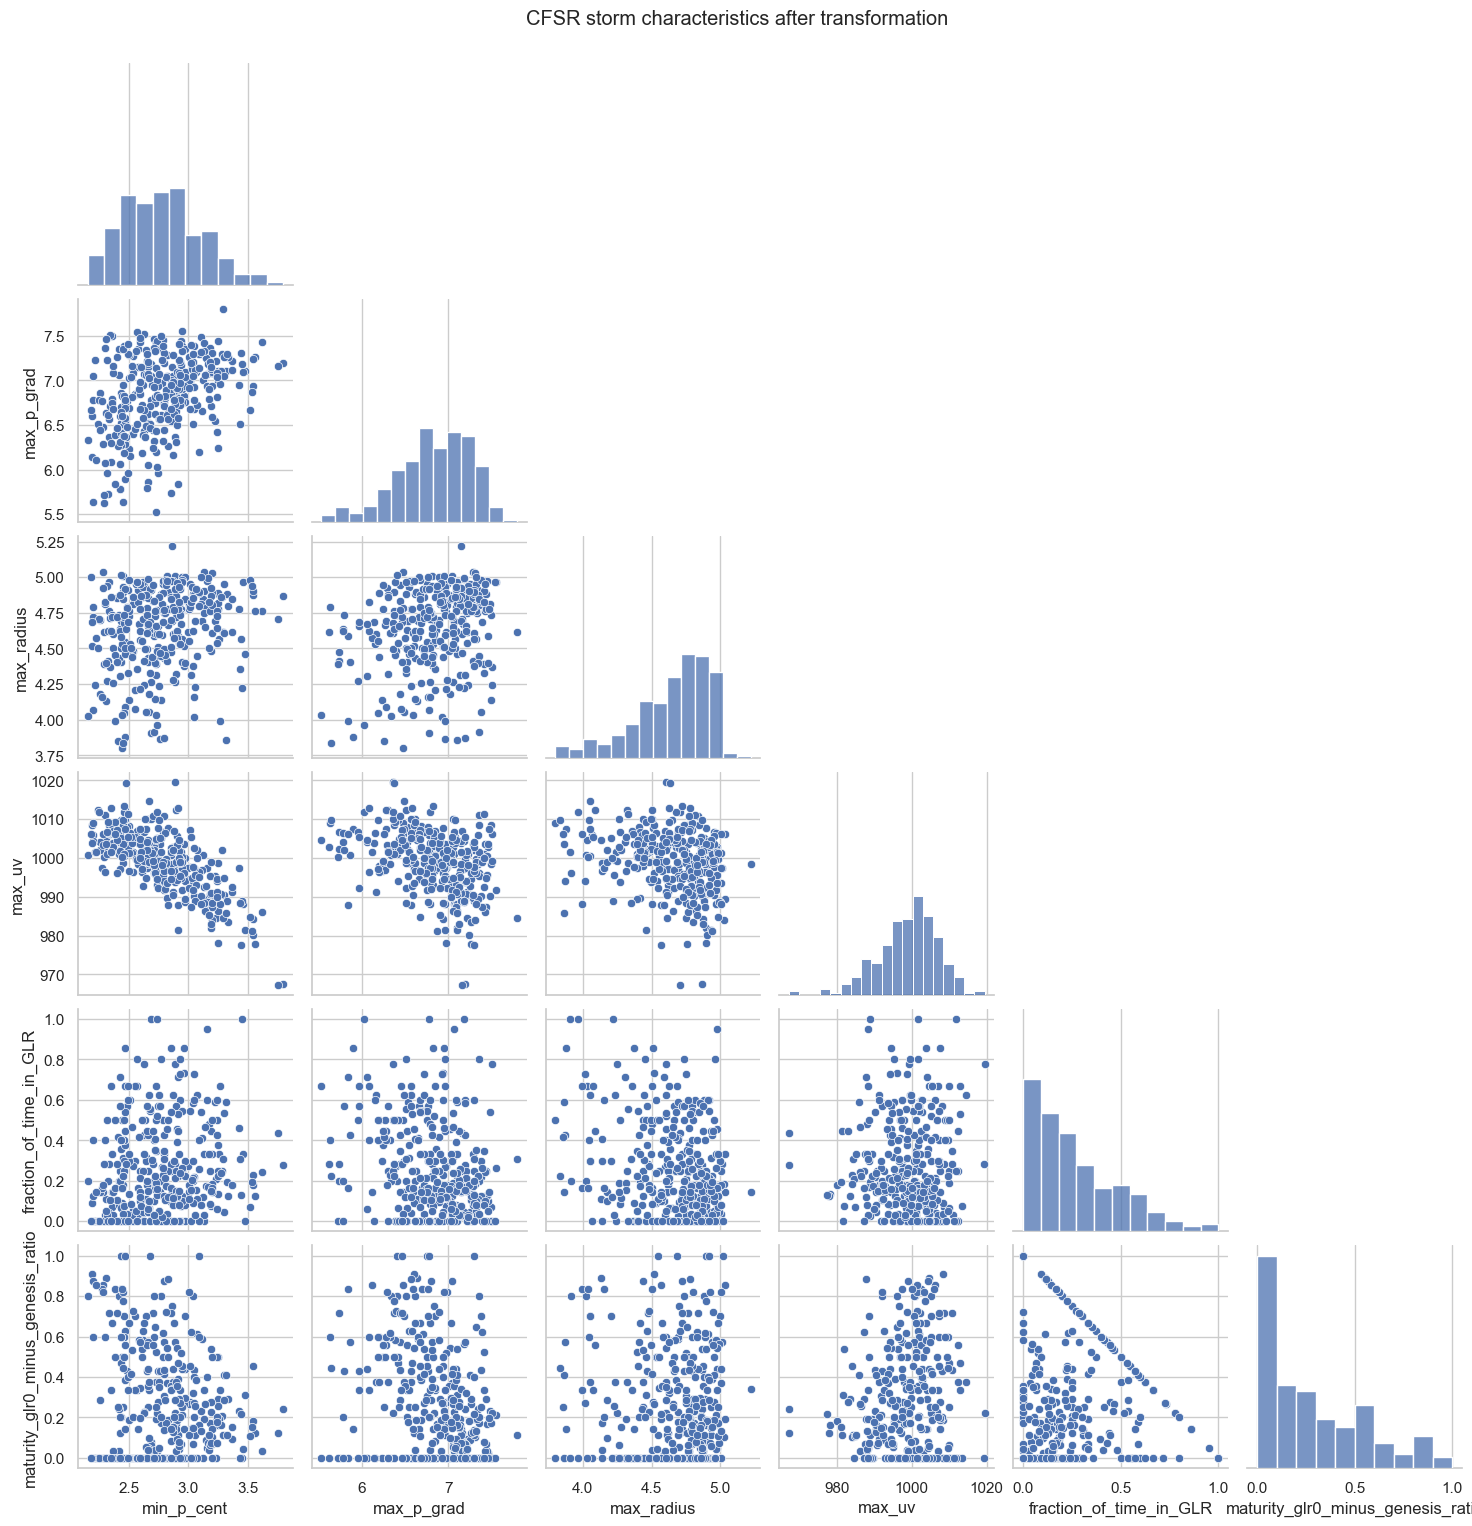

In [22]:
# ------------------------------
# 6. Transform storm characteristics
# ------------------------------
preprocessor = build_transformer()

X_era5 = df_era5[storm_characteristics]
X_cfsr = df_cfsr[storm_characteristics]

X_era5_transformed = preprocessor.fit_transform(X_era5)
X_cfsr_transformed = preprocessor.transform(X_cfsr)

df_era5_transformed = pd.DataFrame(
    X_era5_transformed,
    columns=storm_characteristics,
    index=df_era5.index,
)

df_cfsr_transformed = pd.DataFrame(
    X_cfsr_transformed,
    columns=storm_characteristics,
    index=df_cfsr.index,
)

# Optional diagnostic: transformed storm characteristics
sns.pairplot(
    df_cfsr_transformed.sample(frac=0.1, random_state=42),
    corner=True
)
plt.suptitle("CFSR storm characteristics after transformation", y=1.02)
plt.show()

In [23]:
# ------------------------------
# 7. Transform impacts
# ------------------------------
impact_transformer = build_impact_transformer()

X_era5_impact = df_era5[impact_vars]
X_cfsr_impact = df_cfsr[impact_vars]

X_era5_impact_trans = impact_transformer.fit_transform(X_era5_impact)
X_cfsr_impact_trans = impact_transformer.transform(X_cfsr_impact)

df_era5_impact_trans = pd.DataFrame(
    X_era5_impact_trans,
    columns=impact_vars,
    index=df_era5.index,
)

df_cfsr_impact_trans = pd.DataFrame(
    X_cfsr_impact_trans,
    columns=impact_vars,
    index=df_cfsr.index,
)

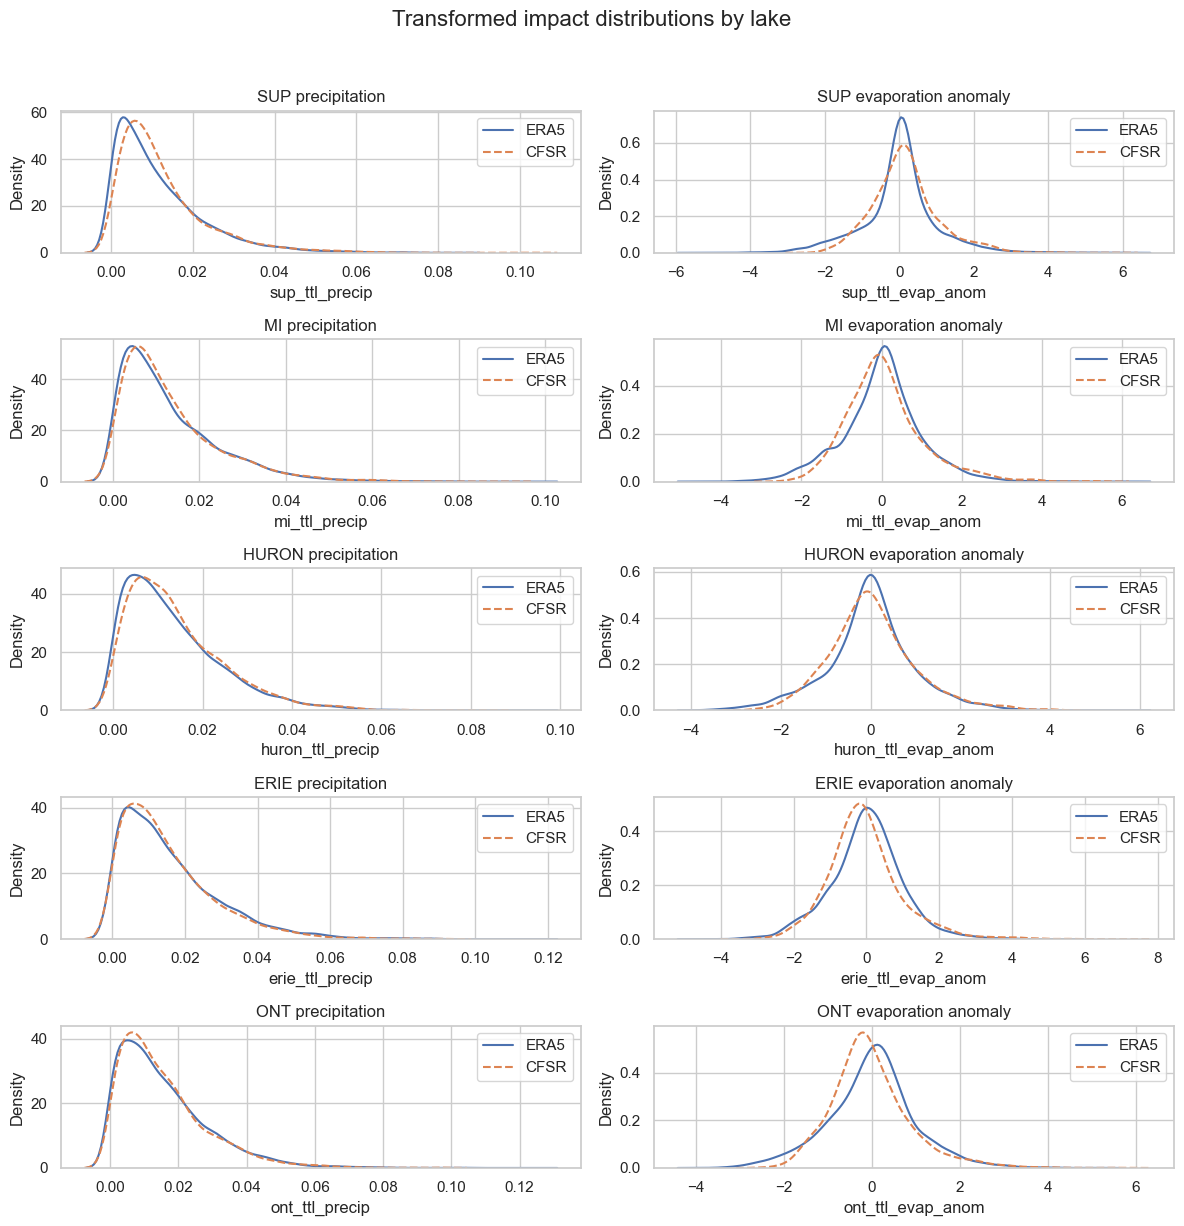

In [24]:
fig, axs = plt.subplots(len(lakes), 2, figsize=(12, 12), sharex=False)
fig.suptitle("Transformed impact distributions by lake", fontsize=16, y=1.02)

for i, lake in enumerate(lakes):
    precip_col = f"{lake}_ttl_precip"
    evap_col = f"{lake}_ttl_evap_anom"

    sns.kdeplot(df_era5_impact_trans[precip_col], ax=axs[i, 0], label="ERA5")
    sns.kdeplot(df_cfsr_impact_trans[precip_col], ax=axs[i, 0], label="CFSR", linestyle="--")
    axs[i, 0].set_title(f"{lake.upper()} precipitation")
    axs[i, 0].legend()

    sns.kdeplot(df_era5_impact_trans[evap_col], ax=axs[i, 1], label="ERA5")
    sns.kdeplot(df_cfsr_impact_trans[evap_col], ax=axs[i, 1], label="CFSR", linestyle="--")
    axs[i, 1].set_title(f"{lake.upper()} evaporation anomaly")
    axs[i, 1].legend()

plt.tight_layout()
plt.show()

## Summary

This notebook provides an overview of the CFSR and ETC datasets and illustrates the preprocessing steps used in later stages of the workflow. The next notebook fits and evaluates the Gaussian mixture model used for storm classification.